<a href="https://www.kaggle.com/code/pushparajput03/cnn-rice-image-dataset?scriptVersionId=316080365" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
## import required libraries

import tensorflow as tf
from tensorflow.keras import layers, models, datasets
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import warnings
warnings.filterwarnings("ignore")

2026-05-02 17:05:57.363392: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777741557.593545      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777741557.664851      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777741558.214977      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777741558.215032      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777741558.215035      16 computation_placer.cc:177] computation placer alr

# Load The Dataset

In [2]:
df = '/kaggle/input/datasets/muratkokludataset/rice-image-dataset/Rice_Image_Dataset'

# Split the image dataset into training and validation sets

In [3]:
train_set = tf.keras.utils.image_dataset_from_directory(
    df,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(150,150),
    batch_size=32
)

val_set = tf.keras.utils.image_dataset_from_directory(
    df,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(150,150),
    batch_size=32
)

Found 75000 files belonging to 5 classes.
Using 60000 files for training.


2026-05-02 17:08:10.463195: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Found 75000 files belonging to 5 classes.
Using 15000 files for validation.


# Visualize Sample Images

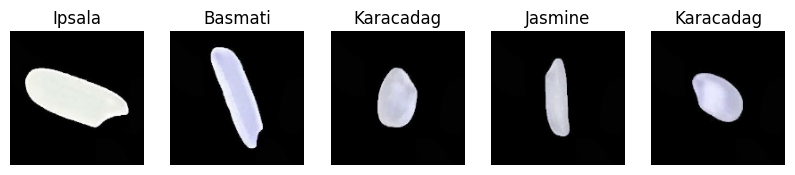

In [4]:
class_names = train_set.class_names

plt.figure(figsize=(10,6))

for images, labels in train_set.take(1):
    for i in range(5):
        plt.subplot(1,5,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

# classes names

In [5]:
class_names = train_set.class_names
print("Classes:", class_names)

Classes: ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']


# Build the CNN Model

In [6]:
cnn = models.Sequential([
    
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(150,150,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.Flatten(),

    layers.Dense(64, activation='relu'),
    layers.Dense(len(class_names), activation='softmax')
])

cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 87616)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     5,607,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,664,133 (21.61 MB)

 Trainable params: 5,664,133 (21.61 MB)

 Non-trainable params: 0 (0.00 B)

# Train Model

In [7]:
cnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model = cnn.fit(train_set, validation_data=val_set, epochs=5 )

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1410s 751ms/step - accuracy: 0.9044 - loss: 2.6275 - val_accuracy: 0.9681 - val_loss: 0.0932
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1455s 747ms/step - accuracy: 0.9717 - loss: 0.0865 - val_accuracy: 0.9729 - val_loss: 0.0791
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1405s 749ms/step - accuracy: 0.9797 - loss: 0.0606 - val_accuracy: 0.9763 - val_loss: 0.0703
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1424s 759ms/step - accuracy: 0.9843 - loss: 0.0460 - val_accuracy: 0.9806 - val_loss: 0.0668
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1410s 752ms/step - accuracy: 0.9891 - loss: 0.0333 - val_accuracy: 0.9822 - val_loss: 0.0676


# Training Performance Visualization

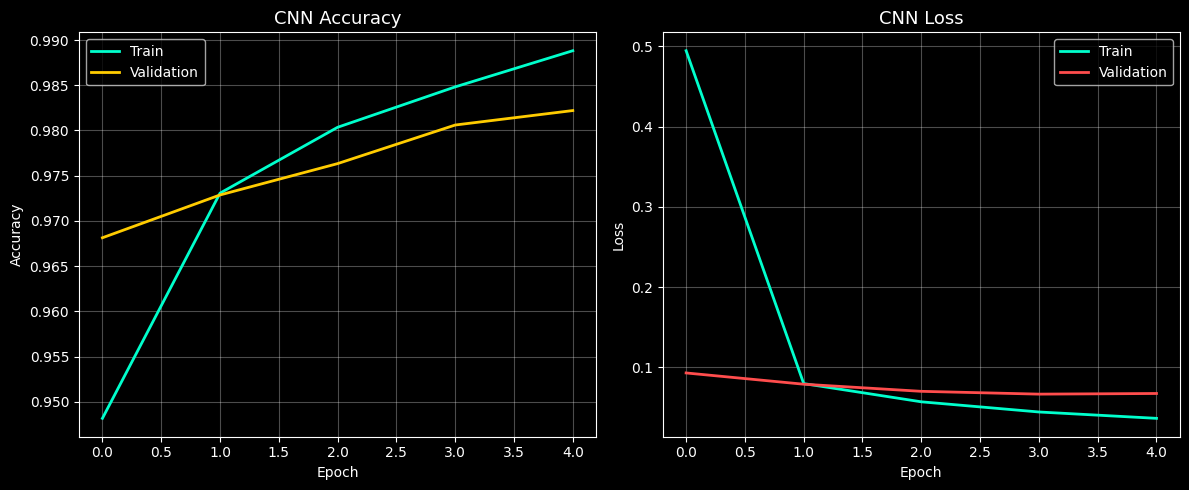

In [8]:
plt.style.use("dark_background")

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(model.history['accuracy'], color="#00ffcc", linewidth=2)
plt.plot(model.history['val_accuracy'], color="#ffcc00", linewidth=2)
plt.title("CNN Accuracy", fontsize=13)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])
plt.grid(alpha=0.3)

# Loss
plt.subplot(1,2,2)
plt.plot(model.history['loss'], color="#00ffcc", linewidth=2)
plt.plot(model.history['val_loss'], color="#ff4d4d", linewidth=2)
plt.title("CNN Loss", fontsize=13)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])
plt.grid(alpha=0.3)


plt.tight_layout()
plt.show()

# This notebook demonstrates how to:

1. Load image data
2. Build a CNN from scratch
3. Train and evaluate a model properly